Ok, we are doing a Y_Field Hypothesis test. Which of our simulations currently explain our experiment best?

1. We can consider the dataset as whole
2. We could also define trajectories in the experiment space. 

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.animation import FuncAnimation
import seaborn as sns
import cupy as cp  
import time
from scipy.interpolate import RectBivariateSpline, RegularGridInterpolator
from scipy.integrate import simpson 

In [2]:
#file paths dely = 0.1
SIM_FILES_1 = {
    "time": r"C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\t_array.csv",
    "freq": r"C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\delz_MHz.csv",
    "data": r"C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\transH_t_vs_Bz_alpha2500_delx_0_dely_0.1.csv"
}

#file paths dely = 0.2
SIM_FILES_2 = {
    "time": r"C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\t_array.csv",
    "freq": r"C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\delz_MHz.csv",
    "data": r"C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\transH_t_vs_Bz_alpha2500_delx_0_dely_0.2.csv"
}

#file paths dely = 0.3
SIM_FILES_3 = {
    "time": r"C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\t_array.csv",
    "freq": r"C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\delz_MHz.csv",
    "data": r"C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\transH_t_vs_Bz_alpha2500_delx_0_dely_0.3.csv"
}

#file paths dely = 0.4
SIM_FILES_4 = {
    "time": r"C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\t_array.csv",
    "freq": r"C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\delz_MHz.csv",
    "data": r"C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\transH_t_vs_Bz_alpha2500_delx_0_dely_0.4.csv"
}

#file paths dely = 0.5
SIM_FILES_5 = {
    "time": r"C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\t_array.csv",
    "freq": r"C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\delz_MHz.csv",
    "data": r"C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\transH_t_vs_Bz_alpha2500_delx_0_dely_0.5.csv"
}

#file paths dely = 0
SIM_FILES_0 = {
    "time": r"C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\t_array.csv",
    "freq": r"C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\delz_MHz.csv",
    "data": r"C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\transH_t_vs_Bz_alpha2500_delx_0_dely_0.csv"
}

EXP_FILES ={
    "time": r"C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Experiment\t_exp.csv",
    "freq_axis": r"C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Experiment\Y_MHz_Exp.csv",
    "data": r"C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Experiment\Probe_trans_Exp.csv"
}

In [3]:
# 6 hypothesis - prior = 1/6
PRIOR_PROBS  = cp.array([1/6]*6)

B_UNKNOWN_FIELD_MHZ = 0.0752

V_DARK_SIM = 0
V_MAX_SIM = 1
V_DARK_EXP = 0
V_MAX_EXP = 0.030

SIM_PULSE_THRESH = 0.2
EXP_PULSE_THRESH = 0.2

In [4]:
#Data loading and pre-processing
def load_simulation(files, v_dark, v_max):
    to = time.time()
    print(f"Loading Simulation from {files['data']}...")
    t = pd.read_csv(files['time'], header = None).values.flatten()
    f = pd.read_csv(files['freq'], header  = None).values.flatten()
    d = pd.read_csv(files['data'], header = None).values

    if d.shape != (len(t),len(f)):
        d = d.T
    print(np.max(d),"\n")
    print(np.min(d),"\n")
    d= calibration(d, v_dark, v_max)
    #d[:, len(f)//2:] = d[:, len(f)//2:] + 2
    spline = RectBivariateSpline(t, f, d, kx = 1, ky = 1)
    print(time.time()-to, "was the time taken to load sim data.")

    return  t,f,spline

def load_experiment(files, v_dark, v_max):
    to = time.time()
    print(f"Loading Experiment from {files['data']}...")
    t = pd.read_csv(files['time'], header = None).values.flatten()
    f_bias = pd.read_csv(files['freq_axis'], header  = None).values.flatten()
    raw_data = pd.read_csv(files['data'], header = None).values

    if raw_data.shape != (len(t),len(f_bias)):
        raw_data = raw_data.T

    calibrated_data= calibration(raw_data, v_dark, v_max)
    print(time.time()-to, "was the time taken to load exp data.")
    return t, f_bias, calibrated_data


#FIXME
def calibration(data, v_dark, v_max):
    scale = 1/(v_max-v_dark)
    calibrated_data = (data-v_dark)*scale
    #calibrated_data = np.clip(calibrated_data,  0.0, 1.0)

    return calibrated_data


#need to check whether this works 
def find_pulse_start(trace, t_axis, threshold):
    idx = np.where(trace>threshold)[0]
    if len(idx)>0:
        return t_axis[idx[0]], idx[0]
    return t_axis[0], 0

In [5]:
def plot_heat_and_surface(X_vec, Y_vec, Z_arr, title_prefix="Data"):
    Xg, Yg = np.meshgrid(X_vec, Y_vec,indexing = 'ij')  # note: meshgrid order (cols = y)
    # heatmap
    plt.figure(figsize=(8,5))
    plt.pcolormesh( Xg, Yg, Z_arr, shading='auto')
    plt.xlabel("time (x)"); plt.ylabel("frequency (y)")
    plt.colorbar(label="Z value")
    plt.title(f"{title_prefix} heatmap (rows=time, cols=freq)")
    plt.tight_layout(); plt.show()
    # 3D surface (might be heavy)
    fig = plt.figure(figsize=(9,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(Yg, Xg, Z_arr, cmap=cm.viridis, linewidth=0, antialiased=True)
    ax.set_xlabel("frequency (y)"); ax.set_ylabel("time (x)"); ax.set_zlabel("Z value")
    plt.title(f"{title_prefix} 3D surface")
    plt.tight_layout(); plt.show()

In [6]:
t_sim_1, f_sim_1, sim_spline_1 = load_simulation(SIM_FILES_1, 0, 1)
t_sim_2, f_sim_2, sim_spline_2 = load_simulation(SIM_FILES_2, 0, 1)
t_sim_3, f_sim_3, sim_spline_3 = load_simulation(SIM_FILES_3, 0, 1)    
t_sim_4, f_sim_4, sim_spline_4 = load_simulation(SIM_FILES_4, 0, 1)
t_sim_5, f_sim_5, sim_spline_5 = load_simulation(SIM_FILES_5, 0, 1)
t_sim_0, f_sim_0, sim_spline_0 = load_simulation(SIM_FILES_0, 0, 1)
t_exp, f_exp, exp_data = load_experiment(EXP_FILES, 0, 1)

Loading Simulation from C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\transH_t_vs_Bz_alpha2500_delx_0_dely_0.1.csv...


7.6376497667125 

0.0 

0.3926122188568115 was the time taken to load sim data.
Loading Simulation from C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\transH_t_vs_Bz_alpha2500_delx_0_dely_0.2.csv...
7.63545738141663 

0.0 

0.5667102336883545 was the time taken to load sim data.
Loading Simulation from C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\transH_t_vs_Bz_alpha2500_delx_0_dely_0.3.csv...
7.63508827551392 

0.0 

0.5653064250946045 was the time taken to load sim data.
Loading Simulation from C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\transH_t_vs_Bz_alpha2500_delx_0_dely_0.4.csv...
7.6349617047049 

0.0 

0.5697546005249023 was the time taken to load sim data.
Loading Simulation from C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\transH_t_vs_Bz_alpha2500_delx_0_dely_0.5.csv...
7.63490321814077 

0.0 

0.5480923652648926 was the time taken to load sim

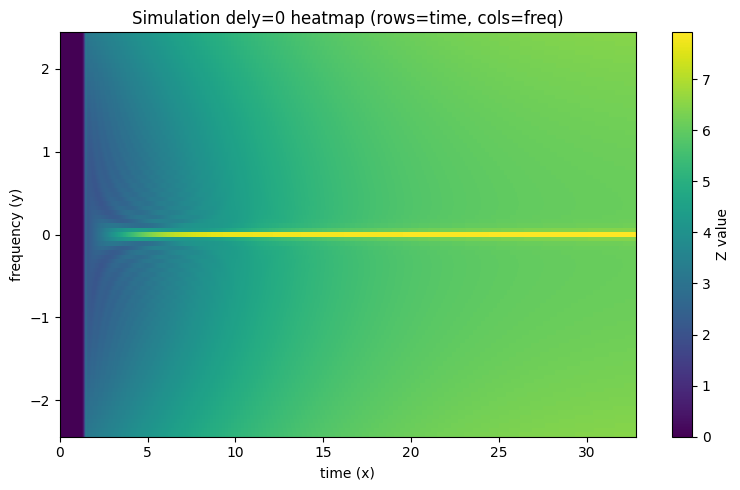

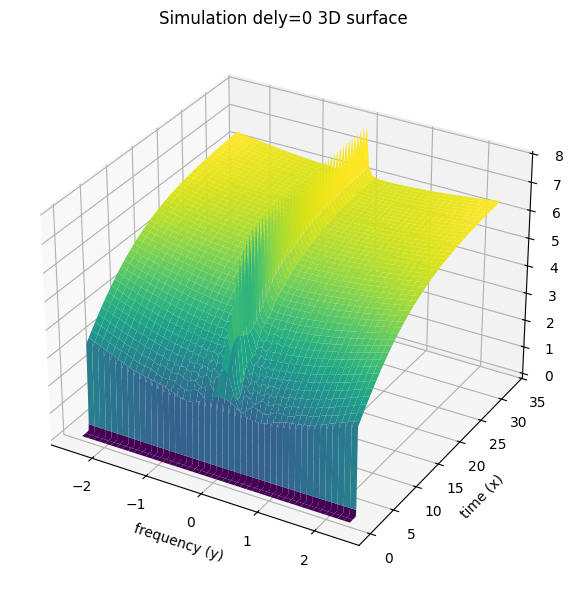

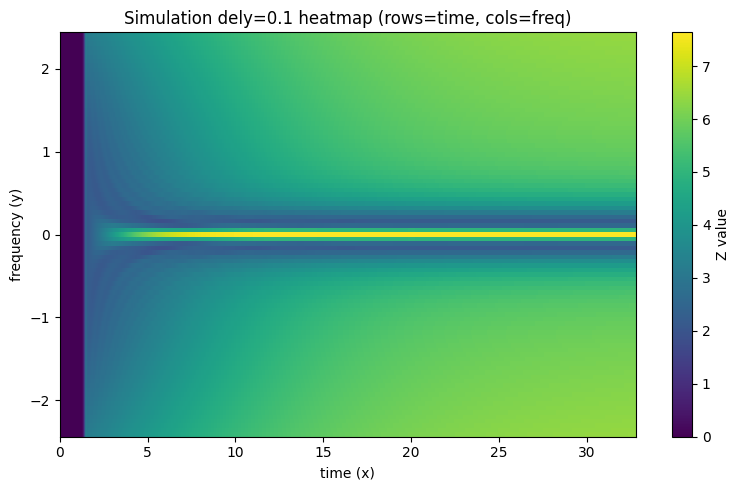

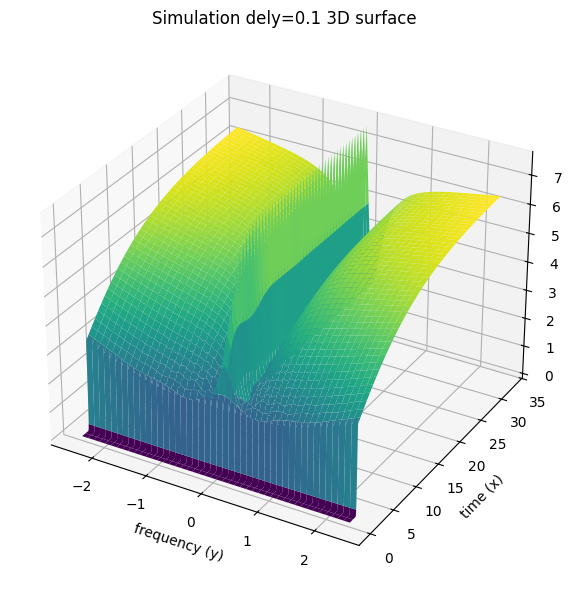

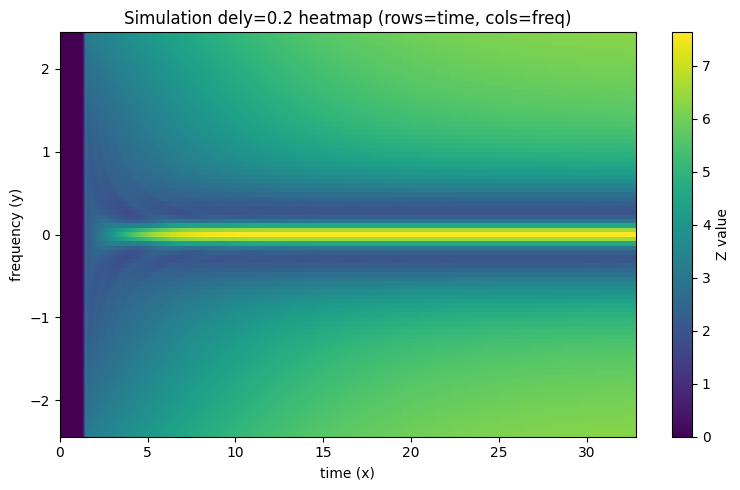

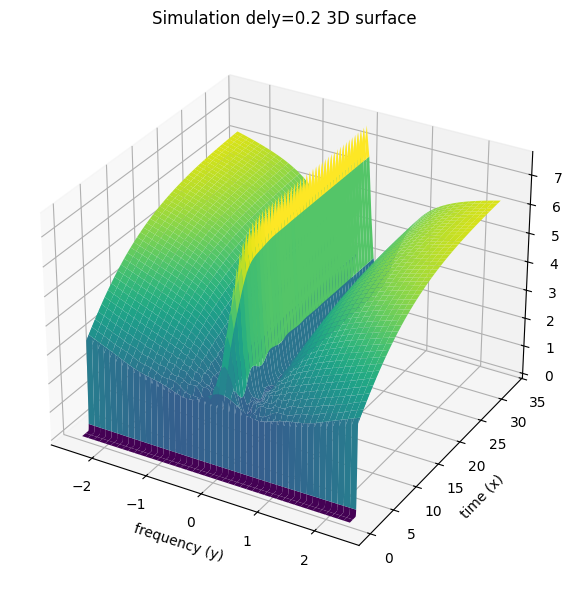

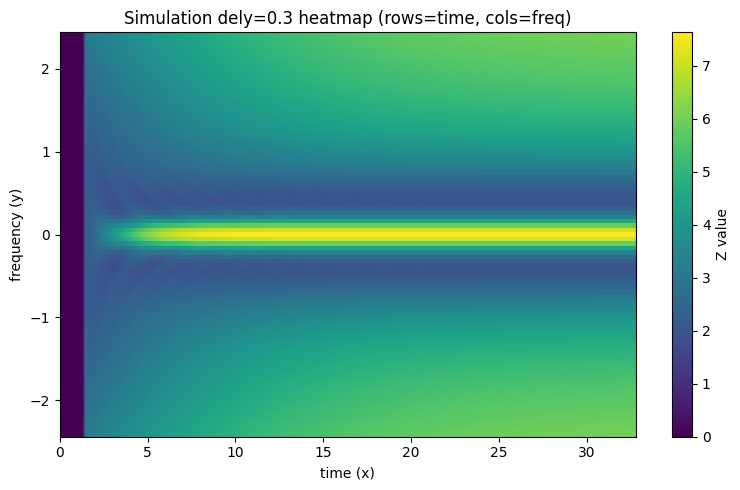

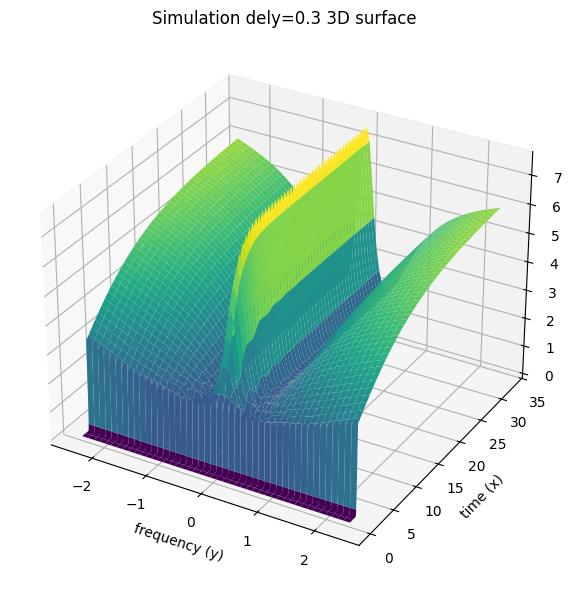

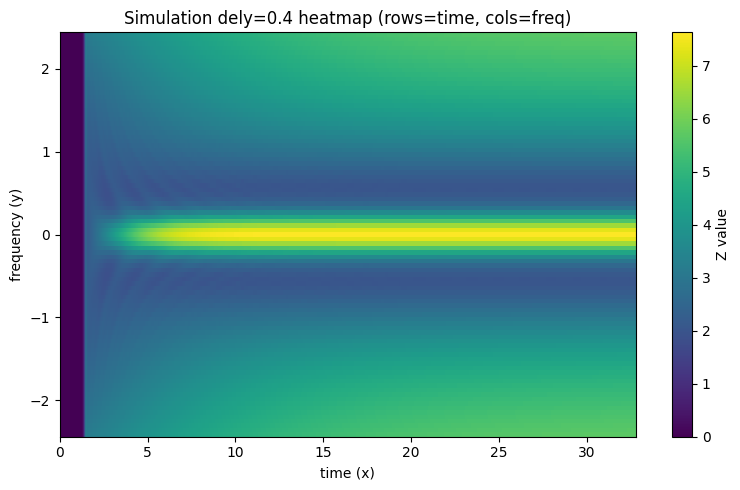

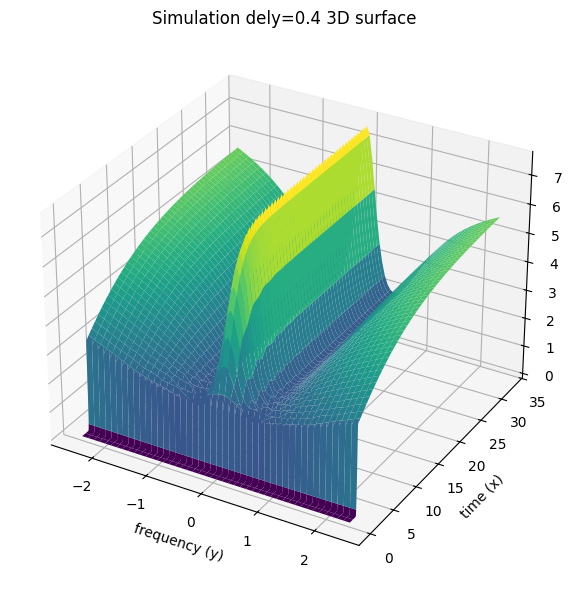

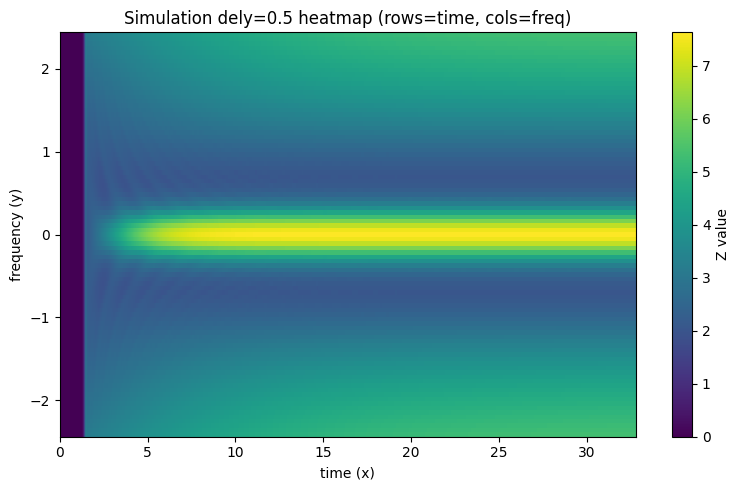

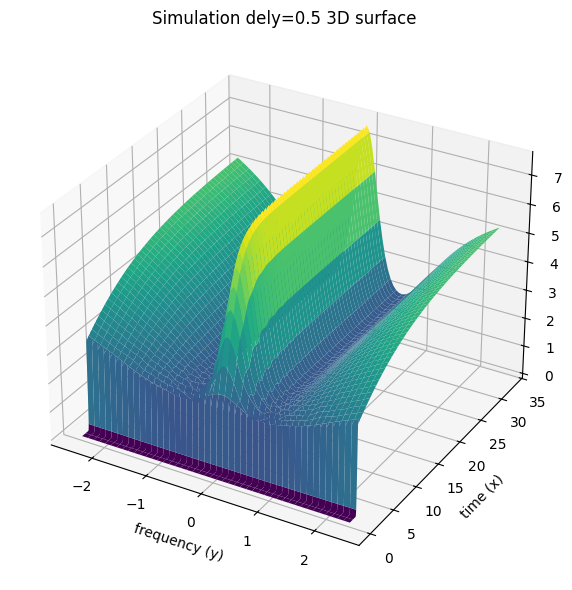

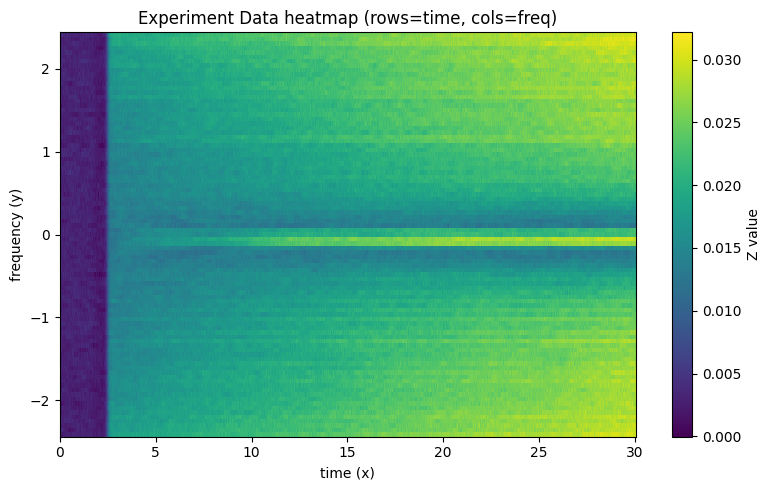

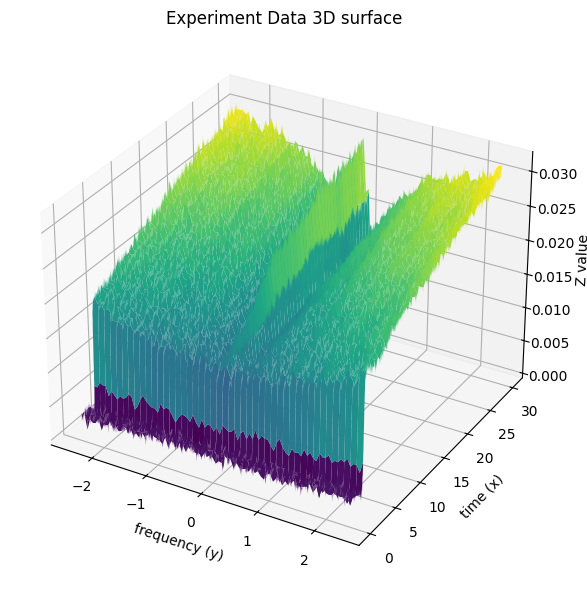

In [7]:
plot_heat_and_surface(t_sim_0, f_sim_0, sim_spline_0(t_sim_0, f_sim_0), title_prefix="Simulation dely=0")
plot_heat_and_surface(t_sim_1, f_sim_1, sim_spline_1(t_sim_1, f_sim_1), title_prefix="Simulation dely=0.1")
plot_heat_and_surface(t_sim_2, f_sim_2, sim_spline_2(t_sim_2, f_sim_2), title_prefix="Simulation dely=0.2")
plot_heat_and_surface(t_sim_3, f_sim_3, sim_spline_3(t_sim_3, f_sim_3), title_prefix="Simulation dely=0.3")
plot_heat_and_surface(t_sim_4, f_sim_4, sim_spline_4(t_sim_4, f_sim_4), title_prefix="Simulation dely=0.4")
plot_heat_and_surface(t_sim_5, f_sim_5, sim_spline_5(t_sim_5, f_sim_5), title_prefix="Simulation dely=0.5")
plot_heat_and_surface(t_exp, f_exp, exp_data, title_prefix="Experiment Data")

We have normalised the data as well, we should not be facing major problems on that end. 

In [8]:
#FIXME need to offset bias axis corresponding to the B_unk longittudinal field

In [9]:
def likelihood_function(sim_spline, exp_data, t_exp, f_exp):
    to =  time.time()
    #sim spline shape = (6, len(t_exp), len(f_exp))
    #shape of numerator_matrix = (6, len(t_exp), len(f_exp))
    sse_matrix = cp.sum((sim_spline - exp_data[None,...])**2, axis=(1,2))
    log_likelihood = -sse_matrix / (2 * (0.05)**2)
    return log_likelihood

def update_posterior(prior, log_likelihood):
    log_prior = cp.log(cp.array(prior))
    log_unnormalized = log_prior + log_likelihood
    max_val = cp.max(log_unnormalized)
    shifted_log = log_unnormalized - max_val
    unnormalized_probs = cp.exp(shifted_log)
    posterior = unnormalized_probs / cp.sum(unnormalized_probs)
    
    return posterior

In [21]:
def run_experiment():
    #load data
    t_sim_1, f_sim_1, sim_spline_1 = load_simulation(SIM_FILES_1, V_DARK_SIM, 7.6376497667125)
    t_sim_2, f_sim_2, sim_spline_2 = load_simulation(SIM_FILES_2, V_DARK_SIM, 7.63545738141663)
    t_sim_3, f_sim_3, sim_spline_3 = load_simulation(SIM_FILES_3, V_DARK_SIM, 7.63508827551392)    
    t_sim_4, f_sim_4, sim_spline_4 = load_simulation(SIM_FILES_4, V_DARK_SIM, 7.6349617047049)
    t_sim_5, f_sim_5, sim_spline_5 = load_simulation(SIM_FILES_5, V_DARK_SIM, 7.63490321814077)
    t_sim_0, f_sim_0, sim_spline_0 = load_simulation(SIM_FILES_0, V_DARK_SIM, 7.91327610041678)

    t_exp, f_exp, exp_data = load_experiment(EXP_FILES, V_DARK_EXP, V_MAX_EXP)
    f_exp += B_UNKNOWN_FIELD_MHZ    

    sim_splines = cp.array([cp.array(sim_spline_0(t_exp,f_exp)), cp.array(sim_spline_1(t_exp,f_exp)), cp.array(sim_spline_2(t_exp,f_exp)), cp.array(sim_spline_3(t_exp,f_exp)), cp.array(sim_spline_4(t_exp,f_exp)), cp.array(sim_spline_5(t_exp,f_exp))])
    exp_data_cp = cp.array(exp_data)

    likelihood = likelihood_function(sim_splines, cp.array(sim_spline_5(t_exp, f_exp)), t_exp, f_exp)
    posterior = update_posterior(PRIOR_PROBS, likelihood)
    print("Posterior probabilities for hypotheses (dely = 0, 0.1, 0.2, 0.3, 0.4, 0.5): ", posterior.get())
    return posterior.get()

In [22]:
print(PRIOR_PROBS, "prior probabilities")
results = run_experiment()

[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667] prior probabilities
Loading Simulation from C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\transH_t_vs_Bz_alpha2500_delx_0_dely_0.1.csv...
7.6376497667125 

0.0 

0.4569284915924072 was the time taken to load sim data.
Loading Simulation from C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\transH_t_vs_Bz_alpha2500_delx_0_dely_0.2.csv...
7.63545738141663 

0.0 

0.4881589412689209 was the time taken to load sim data.
Loading Simulation from C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\transH_t_vs_Bz_alpha2500_delx_0_dely_0.3.csv...
7.63508827551392 

0.0 

0.5157222747802734 was the time taken to load sim data.
Loading Simulation from C:\Users\Dinesh\UGP\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\transH_t_vs_Bz_alpha2500_delx_0_dely_0.4.csv...
7.6349617047049 

0.0 

0.5068309307098389 was the time taken to l

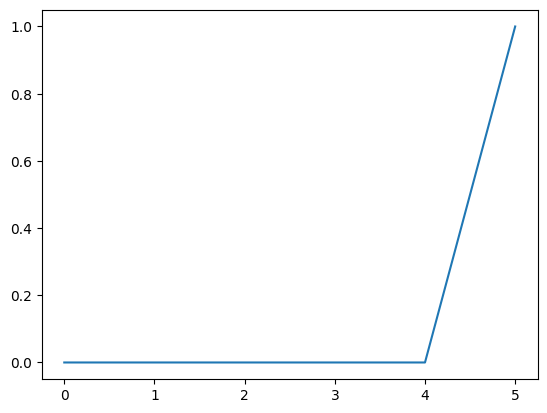

In [23]:
plt.plot([0,1,2,3,4,5], results, label="Posterior probabilities")